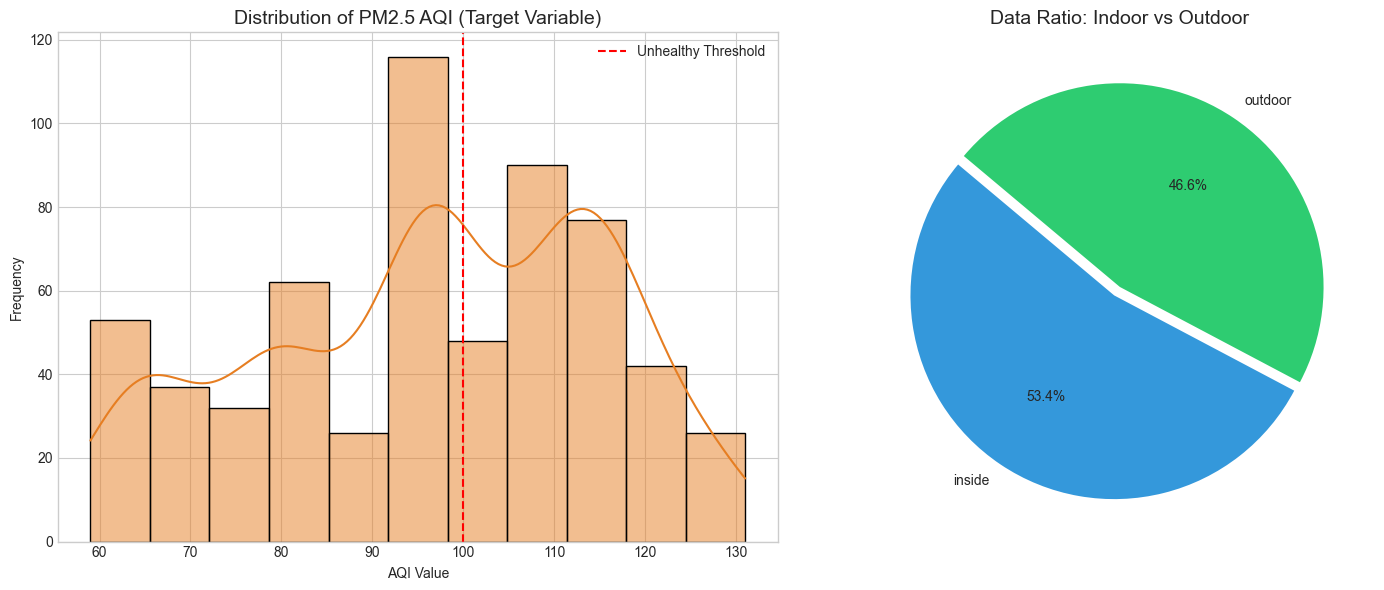

------------------------------
📊 DATA HEALTH SUMMARY
------------------------------
Total Records: 609

Location Split:
place
inside     325
outdoor    284
Name: count, dtype: int64

AQI Stats:
- Mean AQI: 96.47
- Max AQI:  131.00
- Min AQI:  59.00
- Skewness: -0.31

✅ Perfect: No missing values found.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('output/integrated_air_quality_data.csv')


plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.histplot(df['pm25_aqi'], kde=True, ax=axes[0], color='#e67e22')
axes[0].set_title('Distribution of PM2.5 AQI (Target Variable)', fontsize=14)
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')

axes[0].axvline(100, color='red', linestyle='--', label='Unhealthy Threshold')
axes[0].legend()


place_counts = df['place'].value_counts()
axes[1].pie(place_counts, labels=place_counts.index, autopct='%1.1f%%', 
            colors=['#3498db', '#2ecc71'], startangle=140, explode=(0.05, 0))
axes[1].set_title('Data Ratio: Indoor vs Outdoor', fontsize=14)

plt.tight_layout()
plt.show()


print("-" * 30)
print("📊 DATA HEALTH SUMMARY")
print("-" * 30)
print(f"Total Records: {len(df)}")
print(f"\nLocation Split:")
print(place_counts)

print(f"\nAQI Stats:")
print(f"- Mean AQI: {df['pm25_aqi'].mean():.2f}")
print(f"- Max AQI:  {df['pm25_aqi'].max():.2f}")
print(f"- Min AQI:  {df['pm25_aqi'].min():.2f}")
print(f"- Skewness: {df['pm25_aqi'].skew():.2f}")

# เช็ค Missing Values เผื่อหลุด
if df.isnull().sum().sum() > 0:
    print("\n⚠️ Warning: Found missing values!")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("\n✅ Perfect: No missing values found.")